# FraudDetectAI — Credit Card Fraud Detection

Comparing machine learning approaches on a real-world, highly imbalanced dataset 
of European credit card transactions (September 2013, ULB). All features V1–V28 
are PCA-transformed for confidentiality. Data is loaded from PostgreSQL.

## Dataset at a glance
| | |
|---|---|
| Total transactions | 284,807 |
| Fraudulent cases | 492 (0.172%) |
| Features | 30 (V1–V28, Time, Amount, Class) |
| Transaction window | 2 days |

## Approaches compared
- **SMOTE** — synthetic oversampling of the minority class before classification
- **Class weight balancing** — penalises minority misclassification during training
- **Isolation Forest** — anomaly detection, no label balancing required

## Evaluation strategy
Accuracy is misleading on imbalanced data — a model predicting *no fraud* every 
time scores 99.8%. We use AUPRC, ROC-AUC, F1, and SHAP for explainability.

---
*Data source: [ULB Machine Learning Group — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)*

In [26]:
import os
import warnings

# Data
import numpy as np
import pandas as pd

# DB 
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import cross_val_score

# Explainability
import shap

# Settings
SEED = 42
TEST_SIZE = 0.2

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

## Database Connection

In [2]:
load_dotenv()

DB_URL = (
    f"postgresql://"
    f"{os.getenv('POSTGRES_USER', 'postgres')}:"
    f"{os.getenv('POSTGRES_PASSWORD', 'postgres')}@"
    f"localhost:5432/"
    f"{os.getenv('POSTGRES_DB', 'frauddetect')}"
)

engine = create_engine(DB_URL)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM transactions;"))
    count = result.scalar()
    
print(f"Total transactions in the database: {count}")

Total transactions in the database: 284807


**Get Column Names**:

In [3]:
with engine.connect() as conn:
    res = conn.execute(text("SELECT * FROM transactions WHERE 1=0;"))

print("Columns in the dataset:")
print(res.keys())

Columns in the dataset:
RMKeyView(['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class'])


**Class Distribution**

In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
query = """
    SELECT 
        class,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 4) AS percentage
    FROM transactions
    GROUP BY class
    ORDER BY class;
"""

with engine.connect() as conn:
    class_dist = pd.read_sql(text(query), conn)

print("Class distribution:\n")
print(class_dist.to_string(index=False))

Class distribution:

 class  count  percentage
     0 284315     99.8273
     1    492      0.1727


## EDA

In [5]:
# Load the dataset into a DataFrame
query = "SELECT * FROM transactions;"
with engine.connect() as conn:
    df = pd.read_sql(text(query), conn)

print(df.shape)

(284807, 31)


In [6]:
df.head()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [8]:
# Missing values per feature & duplicates
missing_values = df.isnull().sum()[df.isnull().sum() > 0]

print("Missing values per feature:\n")
print(missing_values.to_string())

print(f"\nDuplicated rows: {df.duplicated().sum()}")

Missing values per feature:

Series([], )

Duplicated rows: 1081


In [14]:
# Duplicates per class
dupes = df[df.duplicated(keep=False)]
print(f"Duplicated rows per class:\n{dupes['class'].value_counts()}")

Duplicated rows per class:
class
0    1822
1      32
Name: count, dtype: int64


In [18]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
print(df["class"].value_counts())

(283726, 32)
class
0    283253
1       473
Name: count, dtype: int64


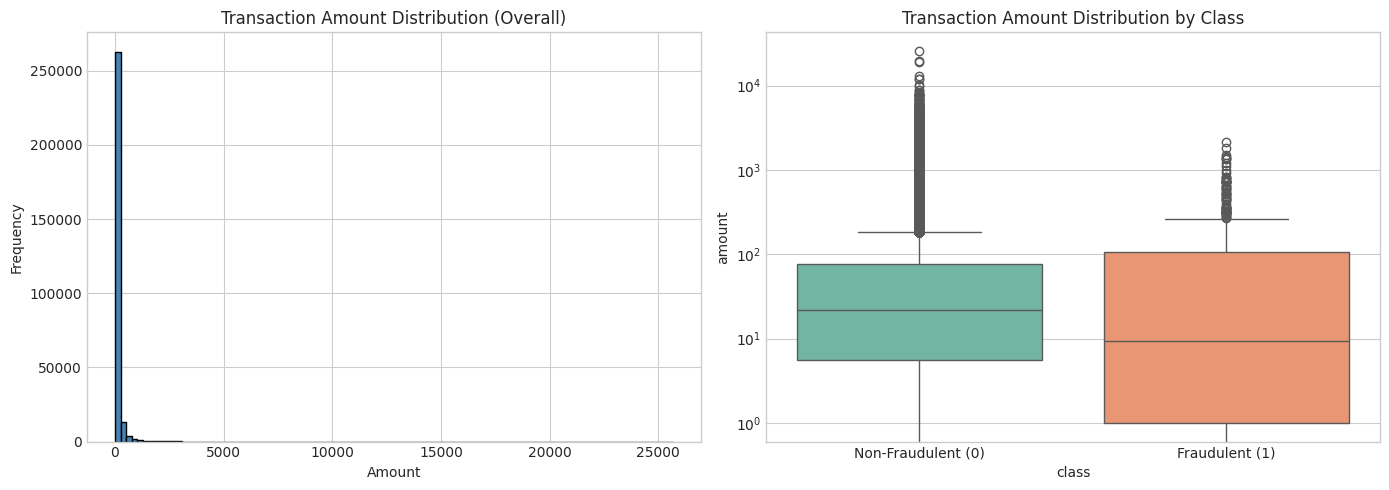

In [9]:
# Amount distribution overall and by class
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax[0].hist(df["amount"], bins=100, color="steelblue", edgecolor="black")
ax[0].set_title("Transaction Amount Distribution (Overall)")
ax[0].set_xlabel("Amount")
ax[0].set_ylabel("Frequency")

# By class distribution
sns.boxplot(data=df, x="class", y="amount", ax=ax[1], palette="Set2")
ax[1].set_title("Transaction Amount Distribution by Class")
ax[1].set_yscale("log")
ax[1].set_xticklabels(["Non-Fraudulent (0)", "Fraudulent (1)"])

plt.tight_layout()
plt.show()

In [10]:
print(df.groupby("class")["amount"].describe())

            count     mean      std    min    25%     50%      75%        max
class                                                                        
0     284315.0000  88.2910 250.1051 0.0000 5.6500 22.0000  77.0500 25691.1600
1        492.0000 122.2113 256.6833 0.0000 1.0000  9.2500 105.8900  2125.8700


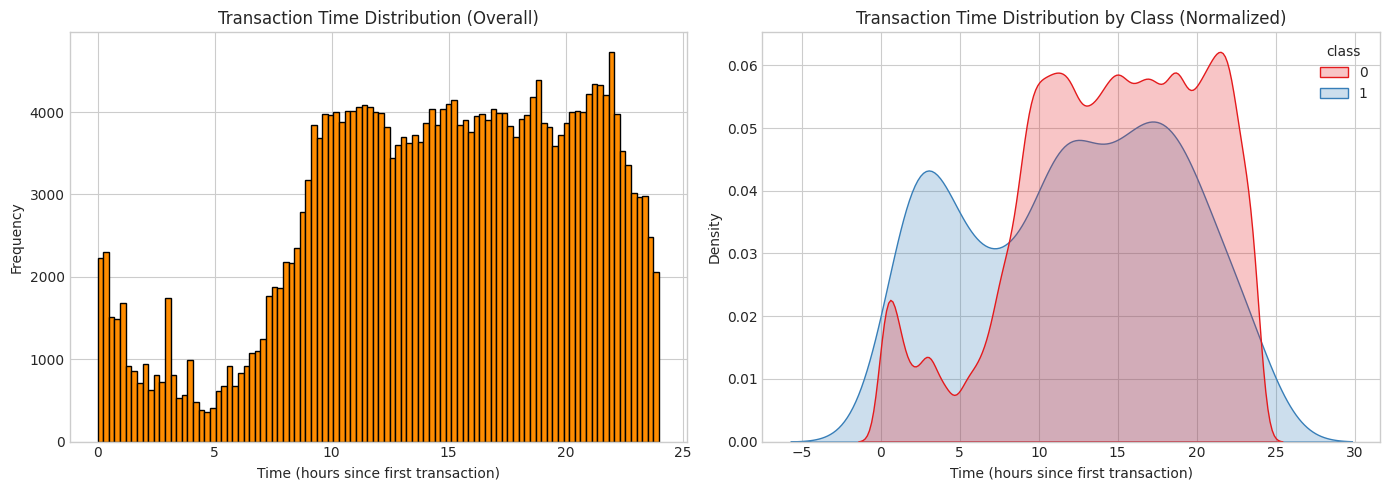

In [ ]:
# Convert time to hours since first transaction
df["hour_of_day"] = (df["time"] % 86400) / 3600

# Time Distribution overall and by class
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Time Distribution overall
ax[0].hist(df["hour_of_day"], bins=100, color="darkorange", edgecolor="black")
ax[0].set_title("Transaction Time Distribution (Overall)")
ax[0].set_xlabel("Time (hours since first transaction)")
ax[0].set_ylabel("Frequency")

# Time Distribution by class
sns.kdeplot(data=df, x="hour_of_day", hue="class", ax=ax[1], fill=True, palette="Set1", common_norm=False)
ax[1].set_title("Transaction Time Distribution by Class (Normalized)")
ax[1].set_xlabel("Time (hours since first transaction)")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [17]:
# Correlation for v1-28
corr_with_class = df.drop(columns=["time", "amount", "hour_of_day"]).corr()["class"].drop("class")
corr_with_class = corr_with_class.reindex(corr_with_class.abs().sort_values(ascending=False).index)

print(corr_with_class)

v17   -0.3265
v14   -0.3025
v12   -0.2606
v10   -0.2169
v16   -0.1965
v3    -0.1930
v7    -0.1873
v11    0.1549
v4     0.1334
v18   -0.1115
v1    -0.1013
v9    -0.0977
v5    -0.0950
v2     0.0913
v6    -0.0436
v21    0.0404
v19    0.0348
v20    0.0201
v8     0.0199
v27    0.0176
v28    0.0095
v24   -0.0072
v13   -0.0046
v26    0.0045
v15   -0.0042
v25    0.0033
v23   -0.0027
v22    0.0008
Name: class, dtype: float64


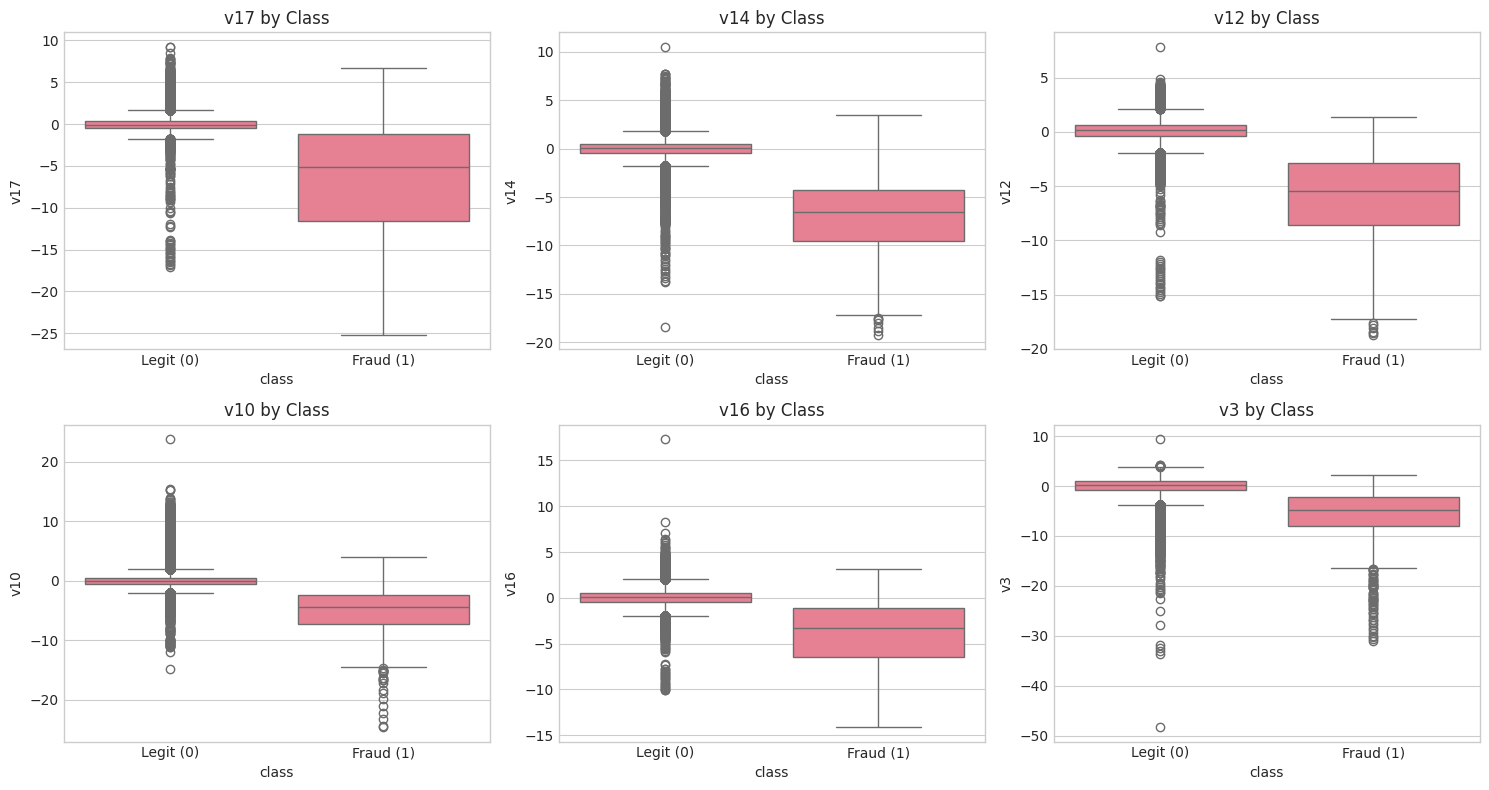

In [20]:
# Visualize top correlated features with class
top_features = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(data=df, x="class", y=feat, ax=axes[i])
    axes[i].set_title(f"{feat} by Class")
    axes[i].set_xticklabels(["Legit (0)", "Fraud (1)"])

plt.tight_layout()
plt.show()

## Model Training

In [22]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print(f"Train shape: {X_train.shape}, Fraud in train: {y_train.sum()}")
print(f"Test shape: {X_test.shape}, Fraud in test: {y_test.sum()}")

Train shape: (226980, 30), Fraud in train: 378
Test shape: (56746, 30), Fraud in test: 95


**Scaling with RobustScaler**

In [23]:
# Scale features
scale_columns = ["amount", "hour_of_day"]

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

X_train_scaled[scale_columns].describe()

,amount,hour_of_day
count,226980.0000,226980.0000
mean,0.9189,-0.0535
std,3.4059,0.6688
min,-0.3060,-1.7195
25%,-0.2271,-0.5048
50%,0.0000,0.0000
75%,0.7729,0.4952
max,272.0960,1.0293


**StratifiedKFold Setup**

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)